Dataset 1:
  GD  steps to ε-neighbourhood: None
  SGD steps to ε-neighbourhood: None


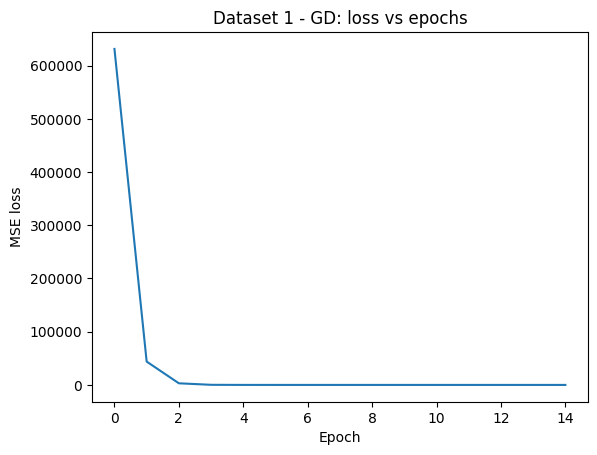

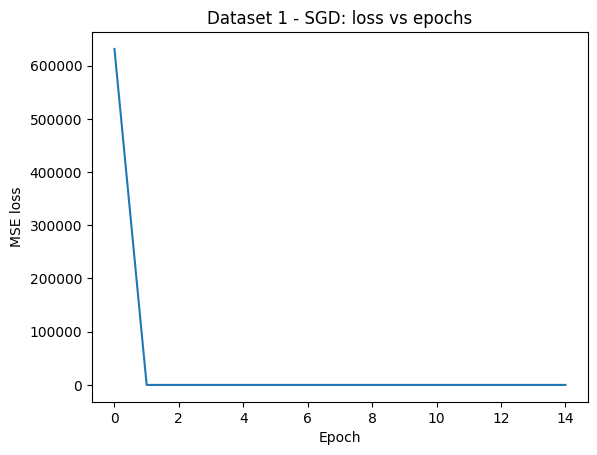

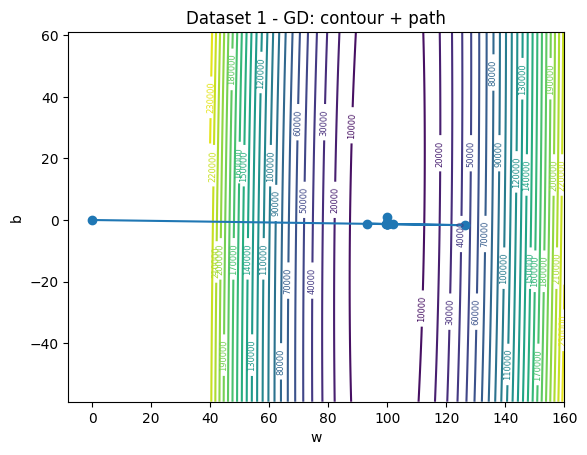

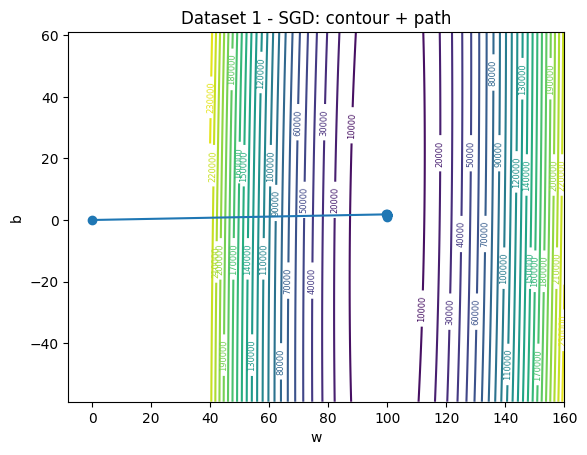


Dataset 2:
  GD  steps to ε-neighbourhood: None
  SGD steps to ε-neighbourhood: None


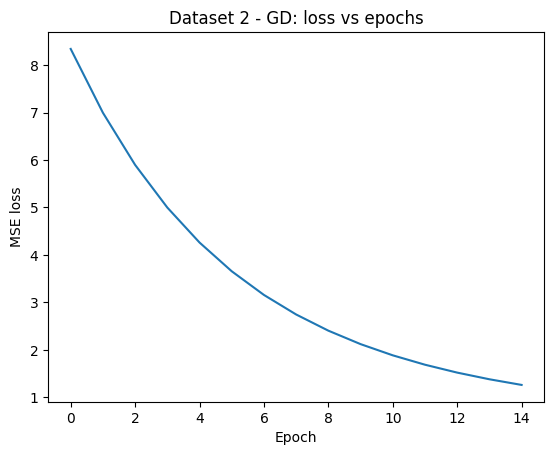

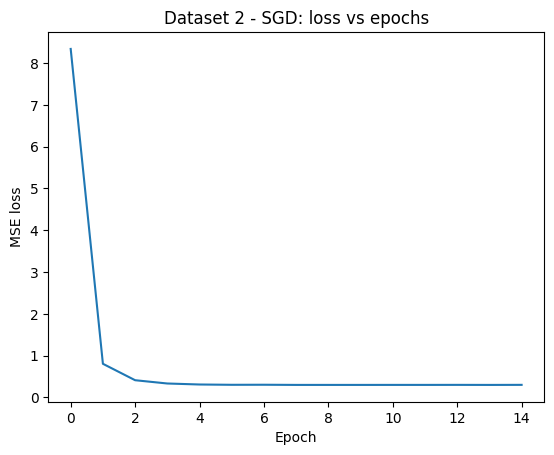

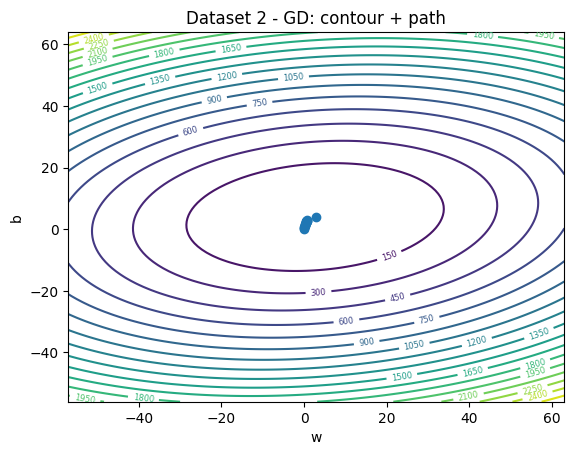

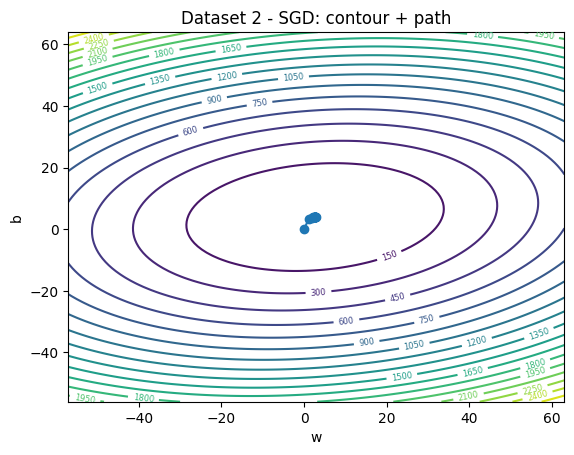


Final θ actual values for Dataset 1:
[100.   1.]

Final θ  values for Dataset 1:
  GD  learned θ = [99.95702303 -1.05495584]
  SGD learned θ = [99.99555266  1.47206741]

Final θ actual values for Dataset 2:
[3. 4.]

Final θ values for Dataset 2:
  GD  learned θ = [0.76116524 2.90066723]
  SGD learned θ = [2.68477234 4.00769618]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------
# 1) Generate the two datasets (as in the question)
# ---------------------------------------------------
def make_dataset_1(n=40):
    np.random.seed(45)
    x = np.random.uniform(-20, 20, n)
    f_x = 100 * x + 1
    eps = np.random.randn(n)
    y = f_x + eps
    return x.reshape(-1, 1), y.reshape(-1, 1)

def make_dataset_2(n=40):
    np.random.seed(45)
    x = np.random.uniform(-1, 1, n)
    f_x = 3 * x + 4
    eps = np.random.randn(n)
    y = f_x + eps
    return x.reshape(-1, 1), y.reshape(-1, 1)

# The add bias is basically converting the z = x1w1 + x2w2 + ... + b into z = xTheta which to convert in vector or matrix is 1 is req 
def add_bias(x):
    # [x] -> [x, 1]
    return np.hstack([x, np.ones((x.shape[0], 1))])

# ---------------------------------------------------
# 2) Helper functions
# ---------------------------------------------------
def mse_loss(X, y, theta):
    y_pred = X @ theta
    return np.mean((y_pred - y)**2) / 2

def get_theta_star_with_sklearn(X, y):
    """
    Use LinearRegression just to get the minimizer θ* on this dataset.
    X already has bias column, so fit_intercept=False.
    """
    lr = LinearRegression(fit_intercept=False)
    lr.fit(X, y.ravel())
    return lr.coef_.reshape(-1, 1)   # shape (2,1): [w, b]

# ---------------------------------------------------
# 3) Gradient Descent (full batch) and SGD
# ---------------------------------------------------
def gradient_descent(X, y, theta_star, lr=0.01, eps=1e-3, max_epochs=15):
    n, d = X.shape
    theta = np.zeros((d, 1))
    theta_history = []
    loss_history = []
    steps_to_conv = None
    steps = 0

    for epoch in range(max_epochs):
        # store for plotting
        theta_history.append(theta.copy())
        loss_history.append(mse_loss(X, y, theta))

        grad = (X.T @ (X @ theta - y)) / n
        theta = theta - lr * grad
        steps += 1

        if steps_to_conv is None and np.linalg.norm(theta - theta_star) < eps:
            steps_to_conv = steps

    return np.array(theta_history), np.array(loss_history), steps_to_conv

def sgd(X, y, theta_star, lr=0.01, eps=1e-3, max_epochs=15):
    n, d = X.shape
    theta = np.zeros((d, 1))
    theta_history = []
    loss_history = []
    steps_to_conv = None
    steps = 0

    for epoch in range(max_epochs):
        theta_history.append(theta.copy())
        loss_history.append(mse_loss(X, y, theta))

        indices = np.random.permutation(n)
        for i in indices:
            xi = X[i:i+1, :]          # (1, d)
            yi = y[i:i+1, :]          # (1, 1)
            grad = xi.T @ (xi @ theta - yi)
            theta = theta - lr * grad
            steps += 1

            if steps_to_conv is None and np.linalg.norm(theta - theta_star) < eps:
                steps_to_conv = steps

    return np.array(theta_history), np.array(loss_history), steps_to_conv

# ---------------------------------------------------
# 4) Plot helpers
# ---------------------------------------------------
def plot_loss(loss_hist, title):
    plt.figure()
    plt.plot(np.arange(len(loss_hist)), loss_hist)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.show()

def plot_contour_with_path(X, y, theta_hist, theta_star, title):
    w_center, b_center = theta_star[0, 0], theta_star[1, 0]
    # simple grid around θ*
    w_vals = np.linspace(w_center - 60, w_center + 60, 120)
    b_vals = np.linspace(b_center - 60, b_center + 60, 120)
    W, B = np.meshgrid(w_vals, b_vals)

    J = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            th = np.array([[W[i, j]], [B[i, j]]])
            J[i, j] = mse_loss(X, y, th)

    plt.figure()
    cs = plt.contour(W, B, J, levels=25)
    plt.clabel(cs, inline=True, fontsize=6)

    path = theta_hist.reshape(len(theta_hist), 2)
    plt.plot(path[:, 0], path[:, 1], marker="o")
    plt.scatter(theta_star[0, 0], theta_star[1, 0])  # true minimizer
    plt.xlabel("w")
    plt.ylabel("b")
    plt.title(title)
    plt.show()

# ---------------------------------------------------
# 5) Run everything
# ---------------------------------------------------
eps = 1e-3

# Dataset 1
x1, y1 = make_dataset_1()
X1 = add_bias(x1)
# theta1_star = get_theta_star_with_sklearn(X1, y1)
theta1_star = np.array([[100.0], [1.0]])
theta_hist_gd1, loss_gd1, steps_gd1 = gradient_descent(X1, y1, theta1_star,
                                                      lr=0.01, eps=eps)
theta_hist_sgd1, loss_sgd1, steps_sgd1 = sgd(X1, y1, theta1_star,
                                             lr=0.001, eps=eps)

print("Dataset 1:")
print("  GD  steps to ε-neighbourhood:", steps_gd1)
print("  SGD steps to ε-neighbourhood:", steps_sgd1)

plot_loss(loss_gd1,  "Dataset 1 - GD: loss vs epochs")
plot_loss(loss_sgd1, "Dataset 1 - SGD: loss vs epochs")
plot_contour_with_path(X1, y1, theta_hist_gd1,  theta1_star,
                       "Dataset 1 - GD: contour + path")
plot_contour_with_path(X1, y1, theta_hist_sgd1, theta1_star,
                       "Dataset 1 - SGD: contour + path")

# Dataset 2
x2, y2 = make_dataset_2()
X2 = add_bias(x2)
# theta2_star = get_theta_star_with_sklearn(X2, y2)
theta2_star = np.array([[3.0], [4.0]])
theta_hist_gd2, loss_gd2, steps_gd2 = gradient_descent(X2, y2, theta2_star,
                                                      lr=0.1, eps=eps)
theta_hist_sgd2, loss_sgd2, steps_sgd2 = sgd(X2, y2, theta2_star,
                                             lr=0.05, eps=eps)

print("\nDataset 2:")
print("  GD  steps to ε-neighbourhood:", steps_gd2)
print("  SGD steps to ε-neighbourhood:", steps_sgd2)

plot_loss(loss_gd2,  "Dataset 2 - GD: loss vs epochs")
plot_loss(loss_sgd2, "Dataset 2 - SGD: loss vs epochs")
plot_contour_with_path(X2, y2, theta_hist_gd2,  theta2_star,
                       "Dataset 2 - GD: contour + path")
plot_contour_with_path(X2, y2, theta_hist_sgd2, theta2_star,
                       "Dataset 2 - SGD: contour + path")

print("\nFinal θ actual values for Dataset 1:")
print(theta1_star.ravel())
print("\nFinal θ  values for Dataset 1:")
print("  GD  learned θ =", theta_hist_gd1[-1].ravel())
print("  SGD learned θ =", theta_hist_sgd1[-1].ravel())

print("\nFinal θ actual values for Dataset 2:")
print(theta2_star.ravel())
print("\nFinal θ values for Dataset 2:")
print("  GD  learned θ =", theta_hist_gd2[-1].ravel())
print("  SGD learned θ =", theta_hist_sgd2[-1].ravel())


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1) Generate the two datasets (as in the question)
def make_dataset_1(n=40):
    np.random.seed(45)
    x = np.random.uniform(-20, 20, n)
    f_x = 100 * x + 1
    eps = np.random.randn(n)
    y = f_x + eps
    return x.reshape(-1, 1), y.reshape(-1, 1)

def make_dataset_2(n=40):
    np.random.seed(45)
    x = np.random.uniform(-1, 1, n)
    f_x = 3 * x + 4
    eps = np.random.randn(n)
    y = f_x + eps
    return x.reshape(-1, 1), y.reshape(-1, 1)

# add bias column so θ = [w, b]
def add_bias(x):
    return np.hstack([x, np.ones((x.shape[0], 1))])

# MSE loss = (1/2n) * sum (ŷ - y)^2
def mse_loss(X, y, theta):
    y_pred = X @ theta
    return np.mean((y_pred - y)**2) / 2

# θ* = argmin MSE, via sklearn (normal eqn)
def get_theta_star(X, y):
    lr = LinearRegression(fit_intercept=False)
    lr.fit(X, y.ravel())
    return lr.coef_.reshape(-1, 1)   # shape (2,1)


In [15]:
def gradient_descent(X, y, theta_star, lr=0.01, eps=1e-3, max_epochs=1000):
    n, d = X.shape
    theta = np.zeros((d, 1))
    theta_hist = []
    loss_hist = []
    steps_to_conv = None
    steps = 0

    for epoch in range(max_epochs):
        theta_hist.append(theta.copy())
        loss_hist.append(mse_loss(X, y, theta))

        grad = (X.T @ (X @ theta - y)) / n
        theta = theta - lr * grad
        steps += 1   # one update per epoch

        if steps_to_conv is None and np.linalg.norm(theta - theta_star) < eps:
            steps_to_conv = steps

    return np.array(theta_hist), np.array(loss_hist), steps_to_conv

def sgd(X, y, theta_star, lr=0.01, eps=1e-3, max_epochs=1000):
    n, d = X.shape
    theta = np.zeros((d, 1))
    theta_hist = []
    loss_hist = []
    steps_to_conv = None
    steps = 0

    for epoch in range(max_epochs):
        theta_hist.append(theta.copy())
        loss_hist.append(mse_loss(X, y, theta))

        indices = np.random.permutation(n)
        for i in indices:
            xi = X[i:i+1, :]
            yi = y[i:i+1, :]
            grad = xi.T @ (xi @ theta - yi)
            theta = theta - lr * grad
            steps += 1   # one update per sample in SGD

            if steps_to_conv is None and np.linalg.norm(theta - theta_star) < eps:
                steps_to_conv = steps

    return np.array(theta_hist), np.array(loss_hist), steps_to_conv


In [16]:
def momentum_gd(X, y, theta_star, lr=0.01, beta=0.9,
                eps=1e-3, max_epochs=1000):
    n, d = X.shape
    theta = np.zeros((d, 1))
    v = np.zeros((d, 1))   # velocity / momentum

    theta_hist = []
    loss_hist = []
    grad_hist = []
    vel_hist = []

    steps_to_conv = None
    steps = 0

    for epoch in range(max_epochs):
        theta_hist.append(theta.copy())
        loss_hist.append(mse_loss(X, y, theta))

        grad = (X.T @ (X @ theta - y)) / n
        v = beta * v + (1 - beta) * grad
        theta = theta - lr * v
        steps += 1

        grad_hist.append(grad.copy())
        vel_hist.append(v.copy())

        if steps_to_conv is None and np.linalg.norm(theta - theta_star) < eps:
            steps_to_conv = steps

    return (np.array(theta_hist), np.array(loss_hist), steps_to_conv,
            np.array(grad_hist), np.array(vel_hist))


In [17]:
def momentum_sgd(X, y, theta_star, lr=0.01, beta=0.9,
                 eps=1e-3, max_epochs=1000):
    n, d = X.shape
    theta = np.zeros((d, 1))
    v = np.zeros((d, 1))

    theta_hist = []
    loss_hist = []
    grad_hist = []   # store epoch-averaged gradients just for plotting
    vel_hist = []

    steps_to_conv = None
    steps = 0

    for epoch in range(max_epochs):
        theta_hist.append(theta.copy())
        loss_hist.append(mse_loss(X, y, theta))

        indices = np.random.permutation(n)
        epoch_grads = []

        for i in indices:
            xi = X[i:i+1, :]
            yi = y[i:i+1, :]
            grad = xi.T @ (xi @ theta - yi)
            v = beta * v + (1 - beta) * grad
            theta = theta - lr * v
            steps += 1
            epoch_grads.append(grad.copy())

            if steps_to_conv is None and np.linalg.norm(theta - theta_star) < eps:
                steps_to_conv = steps

        # store mean grad over this epoch just for visualization
        grad_hist.append(np.mean(epoch_grads, axis=0))
        vel_hist.append(v.copy())

    return (np.array(theta_hist), np.array(loss_hist), steps_to_conv,
            np.array(grad_hist), np.array(vel_hist))


In [21]:
def average_steps(method_fn, X, y, theta_star,
                  label, runs=10, **kwargs):
    steps_list = []
    for r in range(runs):
        np.random.seed(100 + r)  # affects SGD shuffling
        out = method_fn(X, y, theta_star, **kwargs)
        steps = out[2]   # third return is steps_to_conv
        if steps is None:
            steps = float('inf')
        steps_list.append(steps)
    avg = np.mean(steps_list)
    print(f"{label}: avg steps to ||θ-θ*||<eps = {avg:.2f}")
    return avg, steps_list

# ------------ Prepare data & theta* ------------
x1, y1 = make_dataset_1()
X1 = add_bias(x1)
theta1_star = get_theta_star(X1, y1)

x2, y2 = make_dataset_2()
X2 = add_bias(x2)
theta2_star = get_theta_star(X2, y2)

eps = 1e-3

# ------------ Hyperparameters (you can tweak) ------------
eps = 1e-3  # as required in the assignment

# ===================== Dataset 1 (big slope ~100) =====================
# theta_star = get_theta_star(X1, y1)

# Full-batch GD: needs a bit more epochs because landscape is steep
params_1 = dict(
    lr=0.01,       # stable & reasonably fast
    eps=eps,
    max_epochs=1000
)

# SGD: lots of noisy tiny steps
params_1_sgd = dict(
    lr=0.001,      # larger lrs tend to blow up here
    eps=eps,
    max_epochs=200 # 200 epochs * 40 samples = 8000 updates
)

# Momentum GD: faster than vanilla GD with a slightly higher beta
params_1_mgd = dict(
    lr=0.01,
    beta=0.95,     # stronger momentum helped here
    eps=eps,
    max_epochs=1000
)

# Momentum SGD: mildly larger lr, with moderate momentum
params_1_msgd = dict(
    lr=0.002,
    beta=0.8,
    eps=eps,
    max_epochs=200
)

# ===================== Dataset 2 (slope ~3, small range) =====================
# theta_star = get_theta_star(X2, y2)

# Full-batch GD: can afford a much bigger learning rate
params_2 = dict(
    lr=0.2,        # converges quickly (~O(10^2) steps)
    eps=eps,
    max_epochs=500
)

# SGD: works well with a moderate lr
params_2_sgd = dict(
    lr=0.02,
    eps=eps,
    max_epochs=200
)

# Momentum GD: same lr, but with momentum to cut steps further
params_2_mgd = dict(
    lr=0.2,
    beta=0.8,
    eps=eps,
    max_epochs=500
)

# Momentum SGD: slightly higher lr + momentum, a bit faster than plain SGD
params_2_msgd = dict(
    lr=0.025,
    beta=0.8,
    eps=eps,
    max_epochs=200
)


print("=== Dataset 1 ===")
avg_gd1, _    = average_steps(gradient_descent, X1, y1, theta1_star,
                              "GD (full batch)", **params_1)
avg_sgd1, _   = average_steps(sgd, X1, y1, theta1_star,
                              "SGD", **params_1_sgd)
avg_mgd1, _   = average_steps(momentum_gd, X1, y1, theta1_star,
                              "Momentum GD", **params_1_mgd)
avg_msgd1, _  = average_steps(momentum_sgd, X1, y1, theta1_star,
                              "Momentum SGD", **params_1_msgd)

print("\n=== Dataset 2 ===")
avg_gd2, _    = average_steps(gradient_descent, X2, y2, theta2_star,
                              "GD (full batch)", **params_2)
avg_sgd2, _   = average_steps(sgd, X2, y2, theta2_star,
                              "SGD", **params_2_sgd)
avg_mgd2, _   = average_steps(momentum_gd, X2, y2, theta2_star,
                              "Momentum GD", **params_2_mgd)
avg_msgd2, _  = average_steps(momentum_sgd, X2, y2, theta2_star,
                              "Momentum SGD", **params_2_msgd)


=== Dataset 1 ===
GD (full batch): avg steps to ||θ-θ*||<eps = 789.00
SGD: avg steps to ||θ-θ*||<eps = 5622.90
Momentum GD: avg steps to ||θ-θ*||<eps = 621.00
Momentum SGD: avg steps to ||θ-θ*||<eps = 3679.40

=== Dataset 2 ===
GD (full batch): avg steps to ||θ-θ*||<eps = 128.00
SGD: avg steps to ||θ-θ*||<eps = 1931.70
Momentum GD: avg steps to ||θ-θ*||<eps = 75.00
Momentum SGD: avg steps to ||θ-θ*||<eps = 2059.00
